In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

In [12]:
df = pd.read_json('study_sessions.json')

# Expand the sessions column
expanded_df = df.explode('sessions').reset_index(drop=True)

# Normalize the nested dictionary data in sessions column
sessions_normalized = pd.json_normalize(expanded_df['sessions']).reset_index(drop=True)

# Combine with the original columns
result_df = pd.concat([expanded_df[['day', 'date']], sessions_normalized], axis=1)

# Ensure correct units
result_df['date'] = pd.to_datetime(result_df['date'])
result_df['session_length'] = pd.to_timedelta(result_df['session_length'])
result_df['start_time_timestamp'] = result_df['date'].dt.strftime('%Y-%m-%d') + ' ' + result_df['start_time']
result_df['start_time_timestamp'] = pd.to_datetime(result_df['start_time_timestamp'])
result_df['end_time_timestamp'] = result_df['date'].dt.strftime('%Y-%m-%d') + ' ' + result_df['end_time']
result_df['end_time_timestamp'] = pd.to_datetime(result_df['end_time_timestamp'])

result_df['weekday'] = result_df['date'].dt.day_name() # day name
result_df['day_of_week'] = result_df['date'].dt.day_of_week
result_df = result_df[['day', 'weekday', 'day_of_week', 'date', 'start_time', 'end_time', 'session_length', 'note', 'start_time_timestamp', 'end_time_timestamp']]

result_df.tail()

,day,weekday,day_of_week,date,start_time,end_time,session_length,note,start_time_timestamp,end_time_timestamp
46,32.0,Tuesday,1,2026-03-10,06:20:02 PM,07:11:29 PM,0 days 00:51:26,worked on networks notes,2026-03-10 18:20:02,2026-03-10 19:11:29
47,32.0,Tuesday,1,2026-03-10,08:46:34 PM,09:30:56 PM,0 days 00:44:22,"worked on more networks notes, taking a break ...",2026-03-10 20:46:34,2026-03-10 21:30:56
48,32.0,Tuesday,1,2026-03-10,09:32:27 PM,10:08:21 PM,0 days 00:35:54,"finished networks notes, and got wireshark wor...",2026-03-10 21:32:27,2026-03-10 22:08:21
49,33.0,Wednesday,2,2026-03-11,01:22:23 PM,02:49:17 PM,0 days 01:26:54,"getting a job grind omg, i updated my portfoli...",2026-03-11 13:22:23,2026-03-11 14:49:17
50,33.0,Wednesday,2,2026-03-11,08:55:03 PM,10:09:52 PM,0 days 01:14:48,we recently got access to the databricks for t...,2026-03-11 20:55:03,2026-03-11 22:09:52


In [13]:
result_df['start_time_minutes_since_midnight'] = result_df['start_time_timestamp'].dt.hour*60 + result_df['start_time_timestamp'].dt.minute
result_df['end_time_minutes_since_midnight'] = result_df['end_time_timestamp'].dt.hour*60 + result_df['end_time_timestamp'].dt.minute
# result_df

In [14]:
def minutes_to_time(minutes):
    # Extract hour and minute
    # Convert 24-hour to 12-hour format
    # Determine AM/PM
    # Return formatted string
    hour = int(minutes) // 60
    minute = int(minutes) % 60
    period = 'PM'
    # midnight edge case
    if hour < 12 or minutes == 1440:
        period = 'AM'
    
    if hour == 0:
        hour = 12
    if hour > 12:
        hour -= 12

    return f"{hour}:{minute:02d} {period}"

In [15]:
latest_date = result_df['date'].max()
days_since_monday = latest_date.day_of_week
most_recent_monday = latest_date - pd.Timedelta(days=days_since_monday)

week_end = most_recent_monday + pd.Timedelta(days=6)
result_df_filtered = result_df[(result_df['date'] >= most_recent_monday) & (result_df['date'] <= week_end)]

In [16]:
# ============ VISUAL CUSTOMIZATION ============
# Background colors
BG_COLOR = '#11111b'           # Main background
PLOT_BG_COLOR = '#181825'      # Plot area background

# Bar colors
BAR_COLOR = '#94e2d5'          # Main bar color (cyan)
BAR_EDGE_COLOR = '#89b4fa'     # Bar border color
BAR_ALPHA = 0.8                # Bar transparency (0-1)
BAR_WIDTH = 0.8                # Bar width

# Text colors
TEXT_COLOR = '#cdd6f4'         # Main text
TITLE_COLOR = '#cdd6f4'        # Title text
LABEL_COLOR = '#cdd6f4'        # Axis labels

# Grid
GRID_COLOR = '#313244'         # Grid line color
GRID_ALPHA = 0.3               # Grid transparency
GRID_STYLE = '-'              # Grid line style (-- or : or -)

# Font sizes
TITLE_SIZE = 16
LABEL_SIZE = 8
TICK_SIZE = 9
# ============================================

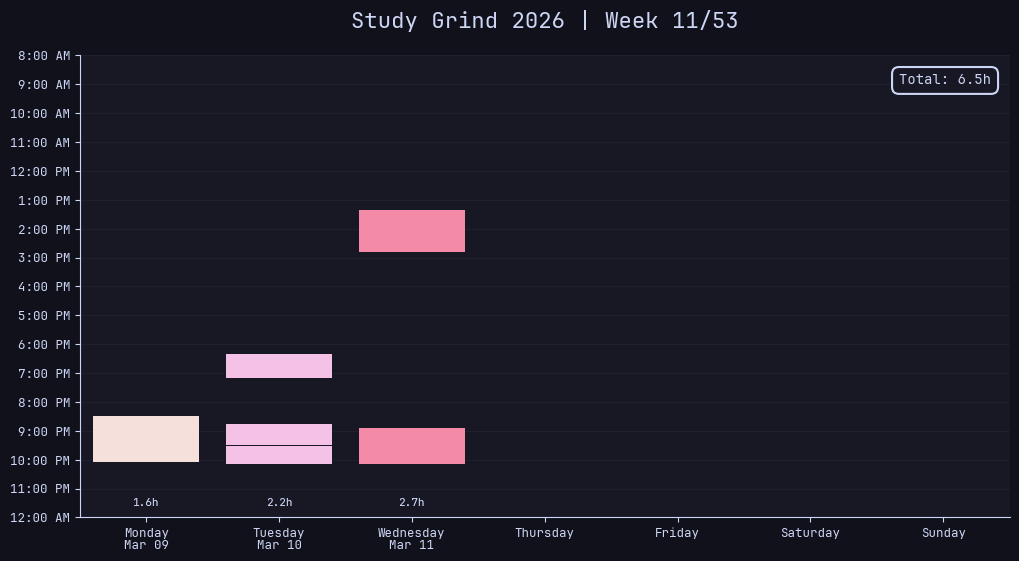

In [17]:
from datetime import date

weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_dates = result_df_filtered.groupby('day_of_week')['date'].first()

WEEKDAY_COLORS = {
    0: '#f5e0dc',  # Monday
    1: '#f5c2e7',  # Tuesday
    2: '#f38ba8',  # Wednesday
    3: '#fab387',  # Thursday
    4: '#a6e3a1',  # Friday
    5: '#89dceb',  # Saturday
    6: '#89b4fa'   # Sunday
}

# Get number of weeks in the current year (52 or 53)
year = datetime.now().year
weeks_in_year = date(year, 12, 28).isocalendar()[1]

x_labels = []
for i in range(7):
    if i in weekday_dates.index:
        date_str = weekday_dates[i].strftime('%b %d')
        x_labels.append(f"{weekday_names[i]}\n{date_str}")
    else:
        x_labels.append(weekday_names[i])  # No data for this day

fig = plt.figure(figsize=(12, 6))
fig.patch.set_facecolor(BG_COLOR)
ax = plt.gca()
ax.set_facecolor(PLOT_BG_COLOR)

for index, row in result_df_filtered.iterrows():
    height = row['end_time_minutes_since_midnight'] - row['start_time_minutes_since_midnight']
    # If session crosses midnight, clip it at midnight
    if height < 0:
        height = 1440 - row['start_time_minutes_since_midnight']
    
    plt.bar(
        row['day_of_week'], 
        height=height,
        bottom=row['start_time_minutes_since_midnight'],
        color=WEEKDAY_COLORS[row['day_of_week']],
        width=BAR_WIDTH,
    )

bbox_props = dict(boxstyle='round,pad=0.5', facecolor=PLOT_BG_COLOR, 
                  edgecolor=TEXT_COLOR, linewidth=1.5)

# Calculate daily totals and add labels above the bottom axis
daily_totals = result_df_filtered.groupby('day_of_week').apply(
    lambda x: (x['end_time_minutes_since_midnight'] - x['start_time_minutes_since_midnight']).sum()
)

for day in daily_totals.index:
    total_hours = daily_totals[day] / 60
    # Calculate daily totals and add labels above the bottom axis
    daily_totals = result_df_filtered.groupby('day_of_week').apply(
        lambda x: (x['end_time_minutes_since_midnight'] - x['start_time_minutes_since_midnight']).sum()
    )

    # Fix negative totals (sessions that cross midnight)
    for day in daily_totals.index:
        if daily_totals[day] < 0:
            daily_totals[day] += 1440

    for day in daily_totals.index:
        total_hours = daily_totals[day] / 60
        y_position = 1420  # Position above the bottom axis (remember y is flipped)
        plt.text(day, y_position, f'{total_hours:.1f}h', 
                    ha='center', va='bottom', color=TEXT_COLOR, 
                    fontsize=LABEL_SIZE, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor=PLOT_BG_COLOR, 
                    edgecolor='none', alpha=0.7))

# Calculate weekly total
weekly_total_hours = daily_totals.sum() / 60

ax.tick_params(colors=TEXT_COLOR, labelsize=TICK_SIZE)
ax.spines['bottom'].set_color(TEXT_COLOR)
ax.spines['left'].set_color(TEXT_COLOR)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=GRID_ALPHA, color=GRID_COLOR, linestyle=GRID_STYLE)

# Font settings
plt.rcParams['font.family'] = 'JetBrains Mono'
plt.rcParams['font.size'] = 10
plt.title(f'Study Grind {datetime.now().isocalendar()[0]} | Week {datetime.now().isocalendar()[1]}/{weeks_in_year}', 
          color=TITLE_COLOR, size=TITLE_SIZE, pad=20)
plt.xticks(range(7), x_labels)
plt.xlim(-0.5, 6.5)  # Extend x-axis so Monday and Sunday are at borders
plt.ylim(1440, 480)  # 0 minutes to 1440 minutes (24 hours), flipped to make beginning of day on top
tick_positions = np.linspace(480, 1440, 17)
tick_labels = [minutes_to_time(t) for t in tick_positions]
plt.yticks(tick_positions, tick_labels)

# Add boxed total hours label in top right
plt.text(0.98, 0.96, f'Total: {weekly_total_hours:.1f}h', 
         transform=ax.transAxes, fontsize=LABEL_SIZE+2, 
         verticalalignment='top', horizontalalignment='right',
         color=TEXT_COLOR, fontweight='bold', bbox=bbox_props)

plt.show();

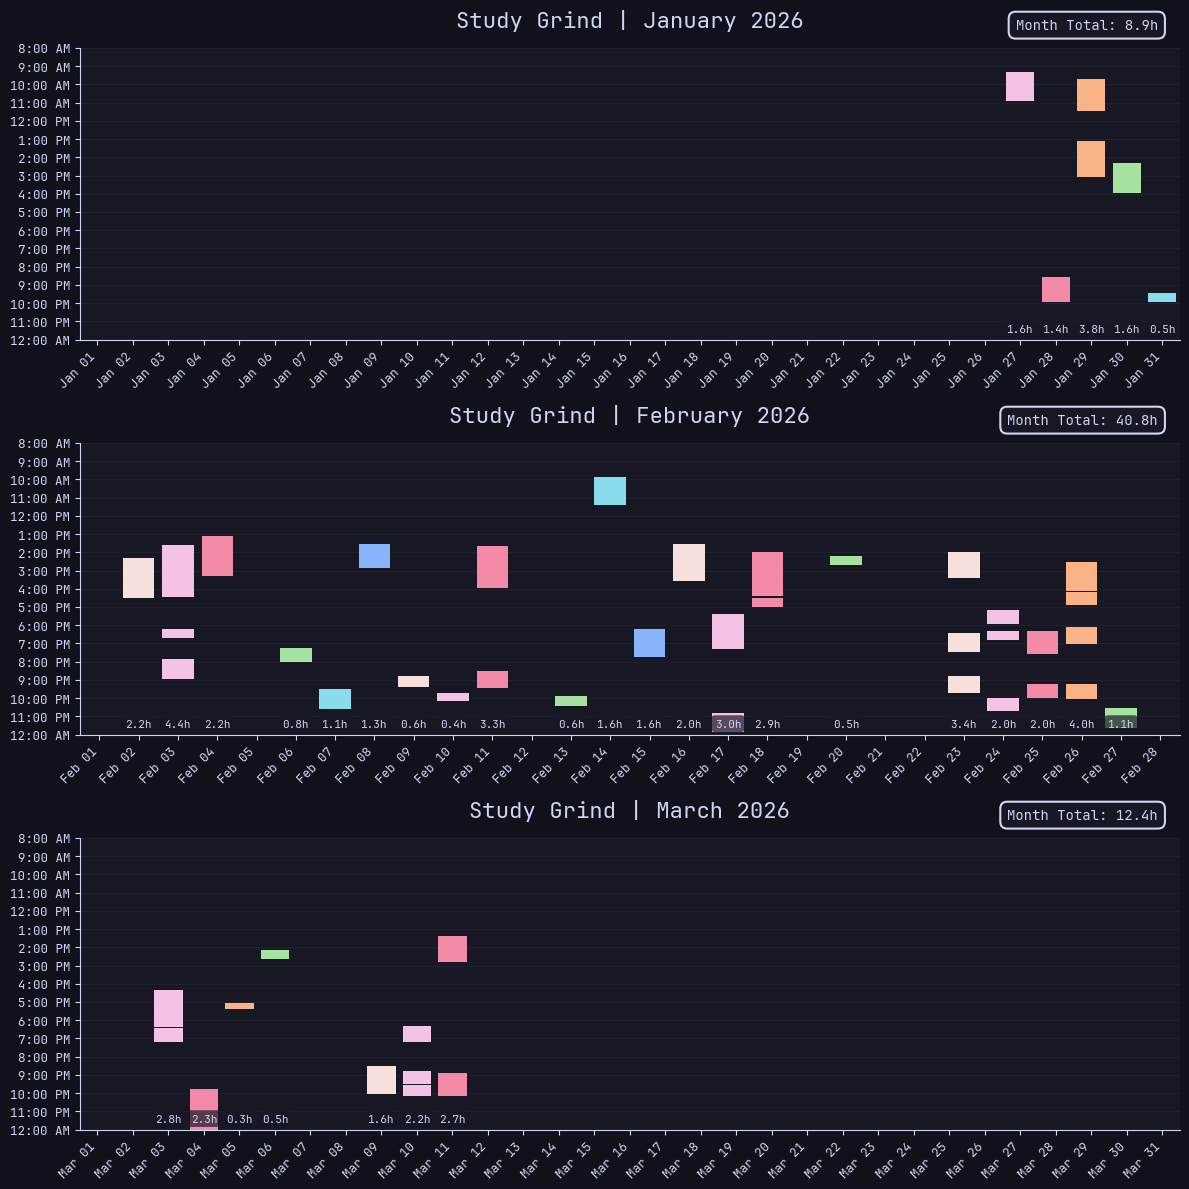

In [18]:
# All data graph - one graph per month stacked vertically
min_date = result_df['date'].min()
max_date = result_df['date'].max()

# Add year-month column
result_df['year_month'] = result_df['date'].dt.to_period('M')

# Get unique months
unique_months = pd.period_range(start=min_date.to_period('M'), end=max_date.to_period('M'), freq='M')
num_months = len(unique_months)

# Create figure with subplots - one row per month
fig, axes = plt.subplots(num_months, 1, figsize=(12, 4 * num_months))
fig.patch.set_facecolor(BG_COLOR)
ax = plt.gca()

# Handle case of single month
if num_months == 1:
    axes = [axes]

bbox_props = dict(boxstyle='round,pad=0.5', facecolor=PLOT_BG_COLOR, 
                  edgecolor=TEXT_COLOR, linewidth=1.5)

# For each month, create a separate graph
for month_idx, month_period in enumerate(unique_months):
    ax = axes[month_idx]
    ax.set_facecolor(PLOT_BG_COLOR)
    
    # Get all dates in this month
    month_start = month_period.to_timestamp()
    month_end = (month_period + 1).to_timestamp() - pd.Timedelta(days=1)
    month_dates = pd.date_range(start=month_start, end=month_end, freq='D')
    
    # Filter data for this month
    month_df = result_df[result_df['year_month'] == month_period].copy()
    
    # Create position mapping for this month
    date_to_position = {date: i for i, date in enumerate(month_dates)}
    month_df['x_position'] = month_df['date'].map(date_to_position)
    
    # Create x-axis labels
    x_labels_month = []
    for d in month_dates:
        date_str = d.strftime('%b %d')
        x_labels_month.append(date_str)
    
    # Plot bars for this month
    for index, row in month_df.iterrows():
        height = row['end_time_minutes_since_midnight'] - row['start_time_minutes_since_midnight']
        # If session crosses midnight, clip it at midnight
        if height < 0:
            height = 1440 - row['start_time_minutes_since_midnight']
        
        ax.bar(
            row['x_position'], 
            height=height,
            bottom=row['start_time_minutes_since_midnight'],
            color=WEEKDAY_COLORS[row['day_of_week']],
            width=BAR_WIDTH
        )
    
    # Calculate daily totals for this month
    if len(month_df) > 0:
        daily_totals_month = month_df.groupby('x_position').apply(
            lambda x: (x['end_time_minutes_since_midnight'] - x['start_time_minutes_since_midnight']).sum()
        )
        
        for pos in daily_totals_month.index:
            if daily_totals_month[pos] < 0:
                daily_totals_month[pos] += 1440
            total_hours = daily_totals_month[pos] / 60
            y_position = 1420
            ax.text(pos, y_position, f'{total_hours:.1f}h', 
                   ha='center', va='bottom', color=TEXT_COLOR, 
                   fontsize=LABEL_SIZE, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor=PLOT_BG_COLOR, 
                            edgecolor='none', alpha=0.7))
        
        # Calculate monthly total
        month_total_hours = daily_totals_month.sum() / 60
    else:
        month_total_hours = 0
    
    # Style the subplot
    ax.tick_params(colors=TEXT_COLOR, labelsize=TICK_SIZE)
    ax.spines['bottom'].set_color(TEXT_COLOR)
    ax.spines['left'].set_color(TEXT_COLOR)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.set_xticks(range(len(month_dates)))
    ax.set_xticklabels(x_labels_month, rotation=45, ha='right')
    ax.set_xlim(-0.5, len(month_dates) - 0.5)  # Extend x-axis so first and last days are at borders
    ax.set_ylim(1440, 480)
    tick_positions = np.linspace(480, 1440, 17)
    tick_labels = [minutes_to_time(t) for t in tick_positions]
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels)
    
    # Title with month name and year
    month_title = month_period.strftime('%B %Y')
    ax.set_title(f'Study Grind | {month_title}', 
                color=TITLE_COLOR, size=TITLE_SIZE, pad=15)
    ax.set_axisbelow(True)
    ax.grid(axis='y', alpha=GRID_ALPHA, color=GRID_COLOR, linestyle=GRID_STYLE)
    
    # Add monthly total box
    ax.text(0.98, 1.1, f'Month Total: {month_total_hours:.1f}h', 
           transform=ax.transAxes, fontsize=LABEL_SIZE+2, 
           verticalalignment='top', horizontalalignment='right',
           color=TEXT_COLOR, fontweight='bold', bbox=bbox_props)

plt.rcParams['font.family'] = 'JetBrains Mono'
plt.rcParams['font.size'] = 10
plt.tight_layout()
plt.show()

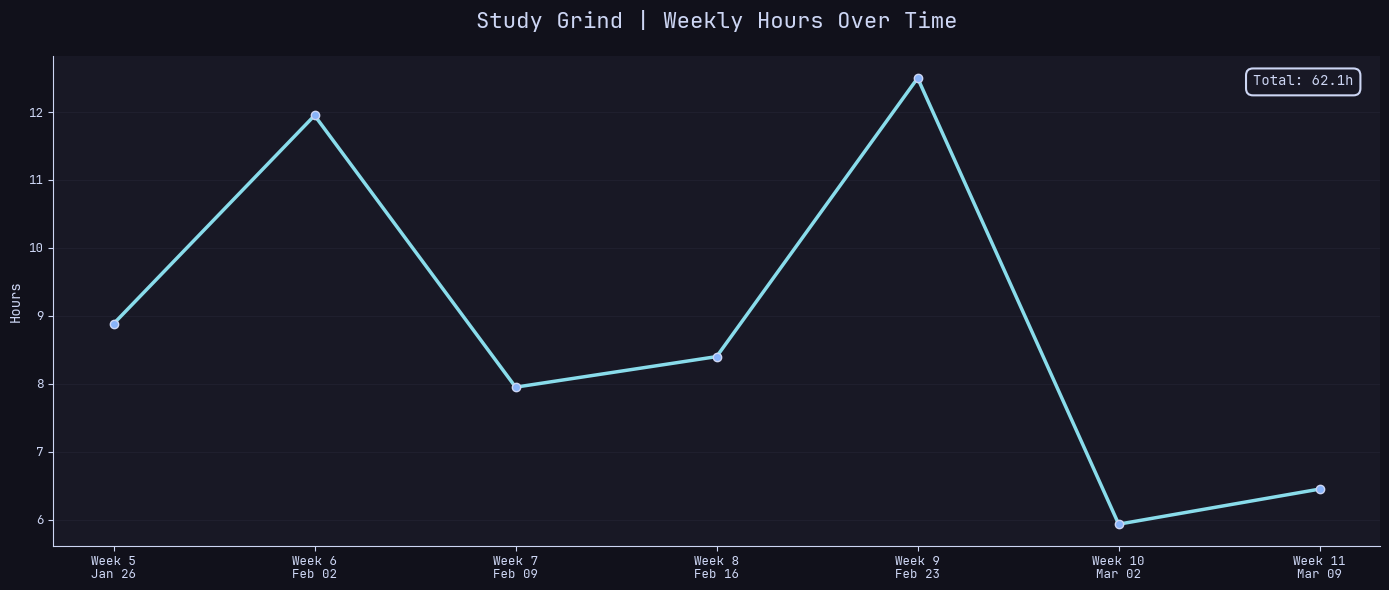

In [19]:
# Weekly hours over time - line graph
result_df['week_start'] = result_df['date'] - pd.to_timedelta(result_df['date'].dt.dayofweek, unit='D')
result_df['year_week'] = result_df['date'].dt.isocalendar().week
result_df['year'] = result_df['date'].dt.isocalendar().year

weekly_hours = result_df.groupby(['year', 'year_week', 'week_start']).apply(
    lambda x: (
        (x['end_time_minutes_since_midnight'] - x['start_time_minutes_since_midnight'])
        .where(
            (x['end_time_minutes_since_midnight'] - x['start_time_minutes_since_midnight']) >= 0,
            (x['end_time_minutes_since_midnight'] - x['start_time_minutes_since_midnight']) + 1440
        )
        .sum() / 60
    )
).reset_index(name='total_hours')

fig = plt.figure(figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)
ax = plt.gca()
ax.set_facecolor(PLOT_BG_COLOR)

plt.plot(range(len(weekly_hours)), weekly_hours['total_hours'], 
         color='#89dceb', linewidth=2.5, marker='o', markersize=6, 
         markerfacecolor='#89b4fa', markeredgecolor='#cdd6f4', markeredgewidth=1)

ax.tick_params(colors=TEXT_COLOR, labelsize=TICK_SIZE)
ax.spines['bottom'].set_color(TEXT_COLOR)
ax.spines['left'].set_color(TEXT_COLOR)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=GRID_ALPHA, color=GRID_COLOR, linestyle=GRID_STYLE)

# Create x-axis labels with week numbers and dates
x_labels_weeks = []
for idx, row in weekly_hours.iterrows():
    week_label = f"Week {row['year_week']}\n{row['week_start'].strftime('%b %d')}"
    x_labels_weeks.append(week_label)

plt.xticks(range(len(weekly_hours)), x_labels_weeks)
plt.ylabel('Hours', color=LABEL_COLOR, fontsize=LABEL_SIZE+2)

plt.rcParams['font.family'] = 'JetBrains Mono'
plt.rcParams['font.size'] = 10
plt.title(f'Study Grind | Weekly Hours Over Time', 
          color=TITLE_COLOR, size=TITLE_SIZE, pad=20)

# Add total hours box
total_all_weeks = weekly_hours['total_hours'].sum()
bbox_props = dict(boxstyle='round,pad=0.5', facecolor=PLOT_BG_COLOR, 
                  edgecolor=TEXT_COLOR, linewidth=1.5)
plt.text(0.98, 0.96, f'Total: {total_all_weeks:.1f}h', 
         transform=ax.transAxes, fontsize=LABEL_SIZE+2, 
         verticalalignment='top', horizontalalignment='right',
         color=TEXT_COLOR, fontweight='bold', bbox=bbox_props)

plt.tight_layout()
plt.show()

In [20]:
# sessions over the past week

latest_date = result_df['date'].max()
start_date = latest_date - pd.Timedelta(days=6)
result_df_last_7_days = result_df[result_df['date'] >= start_date]

print("*" * 32)
print(f"* Sessions over the past week! *")
print("*" * 32)

print(f"Total: {result_df_last_7_days['session_length'].sum()}", end='\n\n')

for name, group in result_df_last_7_days.groupby(['date', 'weekday']):
    total_duration = group['session_length'].sum()
    print("-" * 40)
    print(f"{name[1]} - {name[0].strftime("%b %d %Y")} ({str(total_duration).split(' days ')[1] if ' days ' in str(total_duration) else total_duration})")
    print("-" * 40)
    for row, data in group.iterrows():
        print(f"  {data.start_time} - {data.end_time} ~ {data.note}")

********************************
* Sessions over the past week! *
********************************
Total: 0 days 07:19:51

----------------------------------------
Thursday - Mar 05 2026 (00:21:39)
----------------------------------------
  05:02:18 PM - 05:23:57 PM ~ chill starting sesh, i need to write a sort of literature review for the project thingy and ill try lock in like tonight and full focus it
----------------------------------------
Friday - Mar 06 2026 (00:29:57)
----------------------------------------
  02:10:01 PM - 02:39:59 PM ~ had a few classes today and not a lot of sleep so short session, gonna grind tmmr. worked on networks lab about wireshark and socket programming stuff
----------------------------------------
Monday - Mar 09 2026 (01:34:51)
----------------------------------------
  08:29:11 PM - 10:04:03 PM ~ finished (last weeks) networks lab, starting to get back into the productivity workflow, but this time i think i have a better sleep routine cuz ive kind